In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]

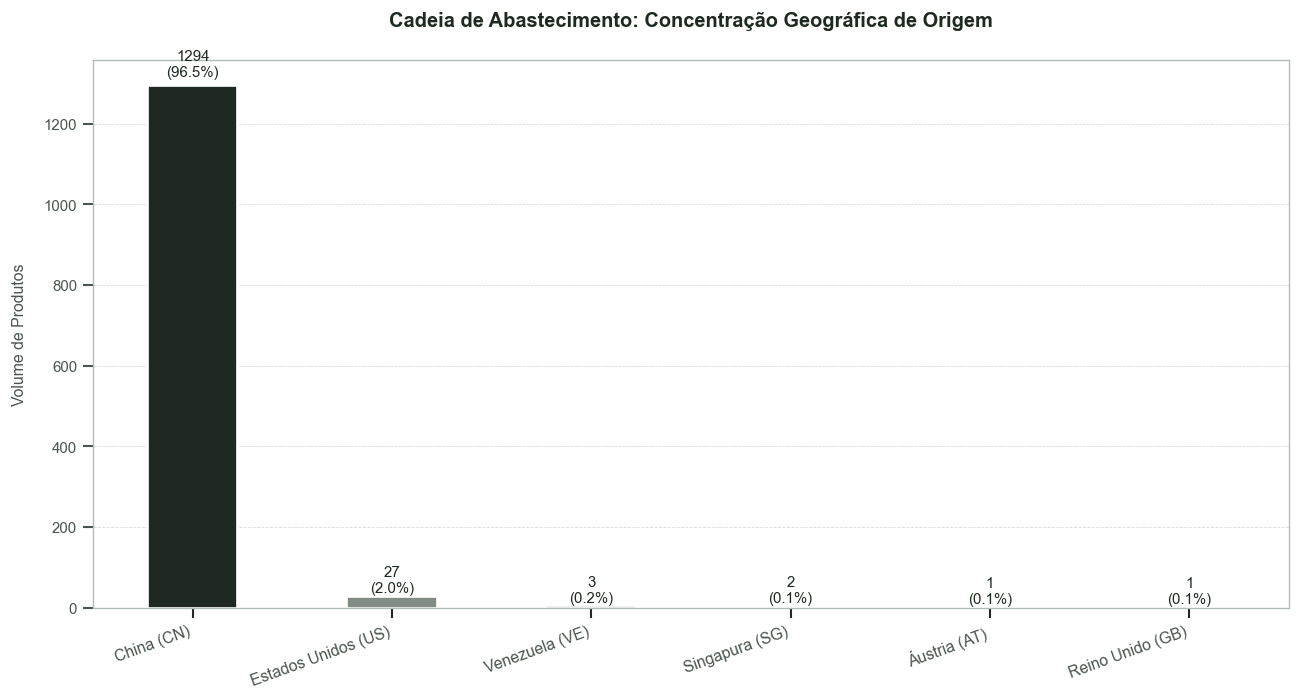

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tratamento de Dados (Preciso e limpo)
limpos_df['origin_countryFix_limpo'] = limpos_df['origin_countryFix'].astype(str).str.strip().str.upper()

valores_para_excluir = ['', 'NAN', 'NONE', ' ']
df_filtrado = limpos_df[~limpos_df['origin_countryFix_limpo'].isin(valores_para_excluir)]

df_origem_real = df_filtrado['origin_countryFix_limpo'].value_counts().reset_index()
df_origem_real.columns = ['Código', 'Quantidade']

mapeamento_paises = {
    'CN': 'China (CN)',
    'US': 'Estados Unidos (US)',
    'VE': 'Venezuela (VE)',
    'SG': 'Singapura (SG)',
    'AT': 'Áustria (AT)',
    'GB': 'Reino Unido (GB)'
}
df_origem_real['País de Origem'] = df_origem_real['Código'].map(mapeamento_paises)

total_validos = df_origem_real['Quantidade'].sum()

ordem_desejada = ['China (CN)', 'Estados Unidos (US)', 'Venezuela (VE)', 'Singapura (SG)', 'Áustria (AT)', 'Reino Unido (GB)']
df_origem_real['País de Origem'] = pd.Categorical(df_origem_real['País de Origem'], categories=ordem_desejada, ordered=True)
df_origem_real = df_origem_real.sort_values('País de Origem')

# 2. Configuração do Gráfico com Grades e Limites de Bloco
paleta_clean = ['#1E2920', '#7E8E83', '#A3B0A7', '#C2CBC5', '#DCE1DD', '#EFEFEF']

plt.figure(figsize=(11, 6), dpi=120)

# Ativamos o estilo 'ticks' para delimitar o bloco e o painel
sns.set_theme(style="ticks")

ax = sns.barplot(
    data=df_origem_real, 
    x='País de Origem', 
    y='Quantidade', 
    hue='País de Origem',
    palette=paleta_clean,
    legend=False,
    width=0.45 
)

# --- ESTRUTURAÇÃO DE LIMITES E GRADES ---
# Ativa grades horizontais finas para dar noção exata de escala/limite
ax.set_axisbelow(True) # Garante que a grade fique atrás das colunas
plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.7)

# Adiciona uma borda fina ao redor de todo o bloco do gráfico para delimitar o espaço
for spine in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#B0BBB4') # Um cinza esverdeado sutil para a moldura
    ax.spines[spine].set_linewidth(0.8)

# Reativa o eixo Y invisível para sabermos os limites numéricos laterais se necessário
plt.gca().get_yaxis().set_visible(True)
plt.ylabel('Volume de Produtos', color='#4A554E', fontsize=9.5, labelpad=10)
ax.tick_params(axis='y', colors='#4A554E', labelsize=9)
# -----------------------------------------

# Adicionar rótulos de dados acima das colunas
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_validos) * 100
        offset = height * 0.012 if height > 50 else 3
        
        ax.text(
            p.get_x() + p.get_width()/2., 
            height + offset, 
            f'{int(height)}\n({pct:.1f}%)', 
            ha="center", 
            va="bottom",
            fontsize=9,
            weight='normal',  
            color='#1E2920'   
        )

# Títulos e formatações dos eixos
plt.title('Cadeia de Abastecimento: Concentração Geográfica de Origem', fontsize=12, pad=20, color='#1E2920', weight='semibold')
plt.xlabel('') 

# Configuração e espaçamento do eixo X
plt.xticks(rotation=20, ha='right', fontsize=9.5, color='#4A554E', weight='normal')

plt.tight_layout()
plt.show()

Média de países destino: 40.68
Máximo de países destino: 140


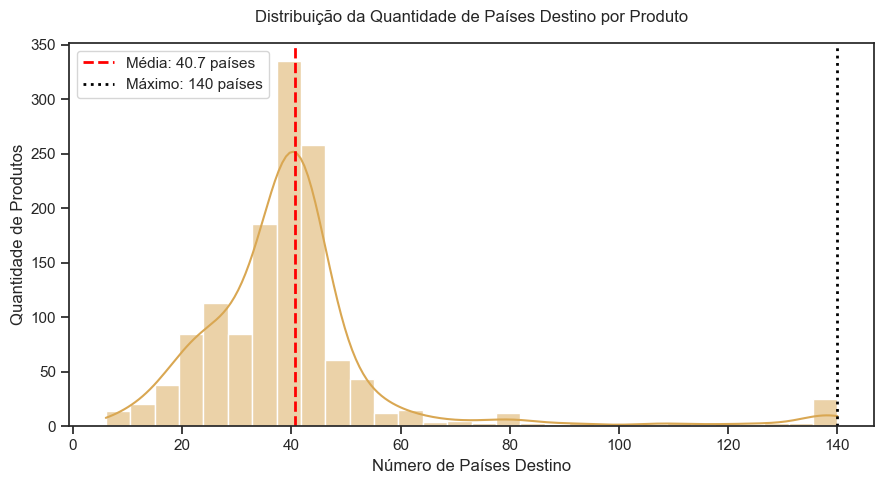

In [3]:
# 1. Tratamento e Isolamento dos Dados
limpos_df['countries_shipped_to_num'] = pd.to_numeric(limpos_df['countries_shipped_to'], errors='coerce')

media_cst = limpos_df['countries_shipped_to_num'].mean()
max_cst = limpos_df['countries_shipped_to_num'].max()

print(f"Média de países destino: {media_cst:.2f}")
print(f"Máximo de países destino: {max_cst}")

# 2. Geração do Gráfico com Seaborn (Histograma de Distribuição)
plt.figure(figsize=(9, 5))
sns.histplot(data=limpos_df, x='countries_shipped_to_num', kde=True, color='#d9a752', bins=30)

# Adicionar linhas indicativas de Média e Máximo
plt.axvline(media_cst, color='red', linestyle='--', linewidth=2, label=f'Média: {media_cst:.1f} países')
plt.axvline(max_cst, color='black', linestyle=':', linewidth=2, label=f'Máximo: {max_cst} países')

plt.title('Distribuição da Quantidade de Países Destino por Produto', fontsize=12, pad=15)
plt.xlabel('Número de Países Destino')
plt.ylabel('Quantidade de Produtos')
plt.legend()
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>